# End-to-End Deep Autoencoding Gaussian Mixture Model (DAGMM)
### Hyperspectral Anomaly Detection with Block-Wise Latent Representations

This notebook implements an end-to-end differentiable DAGMM. It combines a Block-Wise Autoencoder (for feature extraction) with an Estimation Network that predicts GMM memberships, allowing for joint optimization of representations and density estimation.


## 1. Setup and Imports
Loading necessary libraries for deep learning, spectral data analysis, and metrics.


In [55]:
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from tqdm import tqdm
import os
import json
import datetime

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')


Using device: NVIDIA GeForce RTX 5060 Ti


In [56]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True)

set_seed(SEED)

## 2. Configuration and Hyperparameters
Definition of the latent space dimensionality, block-diagonal window structure, and joint loss weights.


In [57]:
# Model Architecture
LATENT_DIM = 64
WINDOW_SIZE = 56
NUM_WINDOWS = 12

# Training
BATCH_SIZE = 1024
LEARNING_RATE = 1e-3

# DAGMM Specific Params
K_COMPONENTS = 12      # Number of GMM components
LAMBDA_ENERGY = 0.01   # Weight for sample energy loss (Updated per Distillation strategy)
LAMBDA_COV = 0.005    # Weight for covariance singularity penalty
COV_EPSILON = 1e-6    # Epsilon for covariance stability

# Training Strategy
AE_WARMUP_EPOCHS = 50      # Stage 1: Train AE only
DISTILL_EPOCHS = 40        # Stage 2: K-Means Distillation (Structural Alignment)
JOINT_FINETUNE_EPOCHS = 20 # Stage 3: Joint optimization

# Evaluation
TOP_K_PERCENT = 1


## 3. Data Loading and Preprocessing
Calibrating raw hyperspectral cubes and preparing independent pixel samples for training (Normal only) and testing.


In [58]:
def load_hsi_data(data_path):
    """Load HSI data from ENVI format."""
    import spectral
    img = spectral.open_image(data_path)
    data = img.load()
    return np.array(data, dtype=np.float32)

def load_label(label_path):
    """Load label data."""
    return np.load(label_path)

def calibrate_hsi(data, white_ref_path, dark_ref_path):
    """Calibrate HSI data using white and dark references."""
    import spectral
    white_ref = np.array(spectral.open_image(white_ref_path).load(), dtype=np.float32)
    dark_ref = np.array(spectral.open_image(dark_ref_path).load(), dtype=np.float32)
    
    white_mean = white_ref.mean(axis=(0, 1))
    dark_mean = dark_ref.mean(axis=(0, 1))
    
    calibrated = (data - dark_mean) / (white_mean - dark_mean + 1e-8)
    calibrated = np.clip(calibrated, 0, 1)
    
    return calibrated

In [59]:
class HSIPixelDataset(Dataset):
    """Dataset that treats each pixel as an independent sample."""
    
    def __init__(self, data, labels=None):
        self.data = data
        self.labels = labels
        
        H, W, B = data.shape
        self.pixels = data.reshape(-1, B)
        
        if labels is not None:
            self.pixel_labels = labels.reshape(-1)
        else:
            self.pixel_labels = None
        
        self.shape = (H, W)
    
    def __len__(self):
        return len(self.pixels)
    
    def __getitem__(self, idx):
        pixel = torch.from_numpy(self.pixels[idx]).float()
        
        if self.pixel_labels is not None:
            label = torch.tensor(self.pixel_labels[idx], dtype=torch.long)
            return pixel, label
        else:
            return pixel

In [60]:
food_type = 'Almond'  # Change to 'Pistachio' or 'GarlicStems' as needed
base_path = f'../../AnomalyonFood/Dataset/{food_type}'

# Load training data (normal only)
train_data_path = f'{base_path}/Train/data.hdr'
train_white_path = f'{base_path}/Train/WHITEREF.hdr'
train_dark_path = f'{base_path}/Train/DARKREF.hdr'

print(f'Loading {food_type} training data...')
train_data = load_hsi_data(train_data_path)
train_data = calibrate_hsi(train_data, train_white_path, train_dark_path)

# Load test data (normal + anomalies)
test_data_path = f'{base_path}/Test/data.hdr'
test_white_path = f'{base_path}/Test/WHITEREF.hdr'
test_dark_path = f'{base_path}/Test/DARKREF.hdr'
test_label_path = f'{base_path}/Test/label.npy'

print(f'Loading {food_type} test data...')
test_data = load_hsi_data(test_data_path)
test_data = calibrate_hsi(test_data, test_white_path, test_dark_path)
test_labels = load_label(test_label_path)

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')
print(f'Test labels shape: {test_labels.shape}')
print(f'Number of bands: {train_data.shape[2]}')

Loading Almond training data...


/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/spectral/io/envi.py:187: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


Loading Almond test data...
Train data shape: (400, 512, 224)
Test data shape: (400, 512, 224)
Test labels shape: (400, 512)
Number of bands: 224


## 4. Model Architecture: Block-Wise DAGMM
Implementing the independent Block-Wise Encoder/Decoder and the differentiable GMM Estimation Network.


In [61]:
train_dataset = HSIPixelDataset(train_data)
test_dataset = HSIPixelDataset(test_data, test_labels)

print(f'Training pixels: {len(train_dataset)}')
print(f'Test pixels: {len(test_dataset)}')
print(f'Spectrum dimension: {train_dataset.pixels.shape[1]}')

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Training pixels: 204800
Test pixels: 204800
Spectrum dimension: 224


In [62]:
class BlockWiseLatentEncoder(nn.Module):
    """BlockWiseLatentEncoder: BLR - Structured Latent Blocks (Explicit Independence)
    
    Split spectrum into windows. Each window encoded independently.
    No mixing layer to preserve block-diagonal covariance structure.
    """
    
    def __init__(self, input_dim, latent_dim=64, window_size=56, num_windows=13):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.window_size = window_size
        self.num_windows = num_windows
        
        # Calculate bands per window
        bands_per_window = input_dim // num_windows
        remainder = input_dim % num_windows
        
        self.bands_per_window = bands_per_window
        self.remainder = remainder
        
        latent_per_window = latent_dim // num_windows
        latent_remainder = latent_dim % num_windows
        
        self.latent_per_window = latent_per_window
        self.latent_remainder = latent_remainder
        
        # Create independent encoders for each block
        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()
        
        for i in range(num_windows):
            # Last window gets remainder bands and latent dims
            if i == num_windows - 1:
                block_input_dim = bands_per_window + remainder
                block_latent_dim = latent_per_window + latent_remainder
            else:
                block_input_dim = bands_per_window
                block_latent_dim = latent_per_window
            
            # Encoder for this block
            encoder = nn.Sequential(
                nn.Linear(block_input_dim, 128),
                nn.ReLU(),
                nn.Linear(128, 64),
                nn.ReLU(),
                nn.Linear(64, block_latent_dim)
            )
            
            # Decoder (mirror)
            decoder = nn.Sequential(
                nn.Linear(block_latent_dim, 64),
                nn.ReLU(),
                nn.Linear(64, 128),
                nn.ReLU(),
                nn.Linear(128, block_input_dim)
            )
            
            self.encoders.append(encoder)
            self.decoders.append(decoder)
    
    def encode(self, x):
        """Encode: split into blocks, encode independently, concatenate."""
        batch_size = x.size(0)
        latents = []
        
        start_idx = 0
        for i in range(self.num_windows):
            if i == self.num_windows - 1:
                block_input_dim = self.bands_per_window + self.remainder
            else:
                block_input_dim = self.bands_per_window
            
            # Extract block
            x_block = x[:, start_idx:start_idx + block_input_dim]
            
            # Encode
            z_block = self.encoders[i](x_block)
            latents.append(z_block)
            
            start_idx += block_input_dim
        
        # Concatenate all block latents
        z = torch.cat(latents, dim=1)
        return z
    
    def decode(self, z):
        """Decode: split latent into blocks, decode independently, concatenate."""
        batch_size = z.size(0)
        reconstructions = []
        
        start_idx = 0
        for i in range(self.num_windows):
            if i == self.num_windows - 1:
                block_latent_dim = self.latent_per_window + self.latent_remainder
            else:
                block_latent_dim = self.latent_per_window
            
            # Extract block
            z_block = z[:, start_idx:start_idx + block_latent_dim]
            
            # Decode
            x_recon = self.decoders[i](z_block)
            reconstructions.append(x_recon)
            
            start_idx += block_latent_dim
        
        # Concatenate all reconstructions
        x_recon = torch.cat(reconstructions, dim=1)
        return x_recon
    
    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return z, x_recon


In [63]:
class EstimationNetwork(nn.Module):
    def __init__(self, latent_dim, num_components):
        super().__init__()
        # MLP to predict mixture memberships - Returns Logits for stability
        self.network = nn.Sequential(
            nn.Linear(latent_dim, latent_dim // 2),
            nn.Tanh(),
            nn.Linear(latent_dim // 2, latent_dim // 4),
            nn.Tanh(),
            nn.Linear(latent_dim // 4, num_components)
        )

    def forward(self, z):
        return self.network(z)

class BlockWiseVAE_DAGMM(nn.Module):
    """End-to-End DAGMM with Block-Wise Latent Representations."""
    
    def __init__(self, input_dim, latent_dim=64, num_windows=12, num_components=5):
        super().__init__()
        self.encoder_ae = BlockWiseLatentEncoder(
            input_dim=input_dim, 
            latent_dim=latent_dim, 
            num_windows=num_windows
        )
        self.estimation_net = EstimationNetwork(latent_dim, num_components)
        
    def forward(self, x):
        # 1. Encode/Decode
        z, x_recon = self.encoder_ae(x)
        
        # 2. Estimate memberships (Logits to Gamma)
        logits = self.estimation_net(z)
        gamma = F.softmax(logits, dim=1)
        
        return z, x_recon, gamma

def compute_gmm_params(z, gamma):
    """Calculate GMM parameters (phi, mu, sigma) from batch data."""
    N = z.shape[0]
    K = gamma.shape[1]
    D = z.shape[1]
    
    # 1. Phi (Component weights) - Eq 4
    gamma_sum = torch.sum(gamma, dim=0) + 1e-10 # [K]
    phi = gamma_sum / N # [K]
    
    # 2. Mu (Means) - Eq 5
    # gamma: [N, K], z: [N, D]
    # mu: [K, D]
    mu = torch.sum(gamma.unsqueeze(-1) * z.unsqueeze(1), dim=0) / gamma_sum.unsqueeze(-1)

    # 3. Sigma (Covariance) - Eq 6
    # z_centered: [N, K, D]
    z_centered = z.unsqueeze(1) - mu.unsqueeze(0) 
    
    sigma = torch.zeros(K, D, D).to(z.device)
    for k in range(K):
        z_k = z_centered[:, k, :] # [N, D]
        gamma_k = gamma[:, k].unsqueeze(-1) # [N, 1]
        
        # Weighted outer product
        cov_k = torch.matmul((z_k * gamma_k).T, z_k) / gamma_sum[k]
        
        # Regularization to prevent singularity
        sigma[k] = cov_k + (torch.eye(D).to(z.device) * COV_EPSILON)
        
    return phi, mu, sigma

def compute_energy(z, phi, mu, sigma):
    """Compute sample energy (Negative Log Likelihood) - Eq 9."""
    N = z.shape[0]
    K = phi.shape[0]
    D = z.shape[1]
    
    z_centered = z.unsqueeze(1) - mu.unsqueeze(0)
    
    energies = []
    for k in range(K):
        inv_sigma = torch.inverse(sigma[k])
        det_sigma = torch.det(sigma[k]) + 1e-30
        
        # Mahalanobis distance
        dist = torch.matmul(torch.matmul(z_centered[:, k, :].unsqueeze(1), inv_sigma), 
                            z_centered[:, k, :].unsqueeze(-1)).squeeze()
        
        log_phi_k = torch.log(phi[k] + 1e-10)
        log_det_k = torch.log(det_sigma)
        log_prob_k = log_phi_k - 0.5 * D * np.log(2 * np.pi) - 0.5 * log_det_k - 0.5 * dist
        energies.append(log_prob_k.unsqueeze(-1))
    
    energies = torch.cat(energies, dim=1)
    sample_energy = -torch.logsumexp(energies, dim=1)
    
    return torch.mean(sample_energy)


In [64]:
input_dim = train_dataset.pixels.shape[1]
print(f'Input dimension: {input_dim}')

# End-to-End DAGMM Model
model = BlockWiseVAE_DAGMM(
    input_dim=input_dim,
    latent_dim=LATENT_DIM,
    num_windows=NUM_WINDOWS,
    num_components=K_COMPONENTS
).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Input dimension: 224
BlockWiseVAE_DAGMM(
  (encoder_ae): BlockWiseLatentEncoder(
    (encoders): ModuleList(
      (0-10): 11 x Sequential(
        (0): Linear(in_features=18, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=5, bias=True)
      )
      (11): Sequential(
        (0): Linear(in_features=26, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=64, bias=True)
        (3): ReLU()
        (4): Linear(in_features=64, out_features=9, bias=True)
      )
    )
    (decoders): ModuleList(
      (0-10): 11 x Sequential(
        (0): Linear(in_features=5, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=18, bias=True)
      )
      (11): Sequential(
        (0): Linear(in_f

## 5. End-to-End Training Strategy
3-Stage Optimization: 
1. **AE Warmup**: Reconstruction only.
2. **GMM Adaptation**: Stabilize estimated Gaussian parameters.
3. **Joint**: Simultaneous optimization for representation and density.


In [67]:
def distill_kmeans_to_gmm(ae_model, gmm_head, dataloader, n_components, epochs=40):
    """Distillation stage: Initialize Estimation Network by learning K-Means clusters."""
    print(f"\n--- Starting Distillation: K-Means(K={n_components}) -> GMM Head ---")
    ae_model.eval()
    gmm_head.train()
    optimizer = torch.optim.Adam(gmm_head.parameters(), lr=1e-3)
    
    # 1. Collect all latents from the frozen AE
    latents = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Collecting latents'):
            if isinstance(batch, (list, tuple)): x = batch[0]
            else: x = batch
            x = x.to(device)
            z, _ = ae_model(x)
            latents.append(z.cpu().numpy())
    latents = np.concatenate(latents, axis=0)

    # 2. Fit K-Means Teacher
    print(f"Fitting K-Means (Teacher) on {len(latents):,} samples...")
    # Removed n_jobs as it is deprecated/removed in newer scikit-learn versions
    kmeans = KMeans(n_clusters=n_components, n_init=10, random_state=SEED).fit(latents)
    
    # 3. Distill into MLP Student (Estimation Network)
    for epoch in range(epochs):
        total_ce_loss = 0
        for batch in dataloader:
            if isinstance(batch, (list, tuple)): x = batch[0]
            else: x = batch
            x = x.to(device)
            
            with torch.no_grad():
                z, _ = ae_model(x)
            
            # Predict labels using fitted KMeans
            labels = torch.tensor(kmeans.predict(z.cpu().numpy()), dtype=torch.long).to(device)
            
            # Forward pass (logits)
            logits = gmm_head(z)
            
            # Loss: Minimize CrossEntropy between MLP and KMeans
            loss = F.cross_entropy(logits, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_ce_loss += loss.item()
            
        if (epoch+1) % 10 == 0 or epoch == 0:
            print(f"Distillation Epoch {epoch+1}/{epochs}: Loss = {total_ce_loss/len(dataloader):.6f}")
    
    print("Distillation complete. GMM Head is now structurally aligned with latent space.")

def train_dagmm_joint(model, loader, ae_warmup_epochs=50, distill_epochs=40, joint_epochs=20):
    """3-Stage DAGMM Training Procedure with K-Means Distillation."""
    
    # 1. Optimizers
    # Stage 1: Encoder/Decoder only
    optimizer_ae = torch.optim.Adam(model.encoder_ae.parameters(), lr=1e-3)
    # Stage 3: Joint
    optimizer_joint = torch.optim.Adam(model.parameters(), lr=1e-4)
    
    history = {
        'recon_loss': [],
        'energy_loss': [],
        'cov_loss': [],
        'total_loss': []
    }
    
    # --- STAGE 1: AE WARMUP ---
    print(f"\n=== Stage 1: AE Warmup ({ae_warmup_epochs} epochs) ===")
    for epoch in range(ae_warmup_epochs):
        model.train()
        train_loss = 0
        for batch in tqdm(loader, desc=f"Warmup {epoch+1}/{ae_warmup_epochs}"):
            if isinstance(batch, (list, tuple)): x = batch[0]
            else: x = batch
            x = x.to(device)
            optimizer_ae.zero_grad()
            z, x_recon = model.encoder_ae(x)
            loss = F.mse_loss(x_recon, x)
            loss.backward()
            optimizer_ae.step()
            train_loss += loss.item()
        history['recon_loss'].append(train_loss / len(loader))
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}: Recon Loss = {train_loss/len(loader):.6f}")

    # --- STAGE 2: K-MEANS DISTILLATION ---
    print(f"\n=== Stage 2: Structural Distillation ({distill_epochs} epochs) ===")
    distill_kmeans_to_gmm(
        ae_model=model.encoder_ae,
        gmm_head=model.estimation_net,
        dataloader=loader,
        n_components=K_COMPONENTS,
        epochs=distill_epochs
    )

    # --- STAGE 3: JOINT OPTIMIZATION ---
    print(f"\n=== Stage 3: Joint Optimization ({joint_epochs} epochs) ===")
    for param in model.parameters():
        param.requires_grad = True
        
    for epoch in range(joint_epochs):
        model.train()
        epoch_recon = 0
        epoch_energy = 0
        epoch_cov = 0
        epoch_total = 0
        
        for batch in tqdm(loader, desc=f"Joint {epoch+1}/{joint_epochs}"):
            if isinstance(batch, (list, tuple)): x = batch[0]
            else: x = batch
            x = x.to(device)
            optimizer_joint.zero_grad()
            
            z, x_recon, gamma = model(x)
            
            phi, mu, sigma = compute_gmm_params(z, gamma)
            
            # Loss Components
            recon_loss = F.mse_loss(x_recon, x)
            energy_loss = compute_energy(z, phi, mu, sigma)
            
            cov_loss = 0
            for k in range(sigma.shape[0]):
                cov_loss += torch.sum(1 / torch.diagonal(sigma[k]))
                
            # Final Joint Loss (using updated LAMBDA_ENERGY)
            total_loss = recon_loss + (LAMBDA_ENERGY * energy_loss) + (LAMBDA_COV * cov_loss)
            
            total_loss.backward()
            optimizer_joint.step()
            
            epoch_recon += recon_loss.item()
            epoch_energy += energy_loss.item()
            epoch_cov += cov_loss.item()
            epoch_total += total_loss.item()
            
        avg_recon = epoch_recon / len(loader)
        avg_energy = epoch_energy / len(loader)
        avg_cov = epoch_cov / len(loader)
        avg_total = epoch_total / len(loader)
        
        history['recon_loss'].append(avg_recon)
        history['energy_loss'].append(avg_energy)
        history['cov_loss'].append(avg_cov)
        history['total_loss'].append(avg_total)
        
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}: Total={avg_total:.6f}, Recon={avg_recon:.6f}, Energy={avg_energy:.6f}, Cov={avg_cov:.6f}")
            
    return history



=== Stage 1: AE Warmup (50 epochs) ===


Warmup 10/50: 100%|██████████| 200/200 [00:02<00:00, 72.00it/s]


Epoch 10: Recon Loss = 0.000514


Warmup 20/50: 100%|██████████| 200/200 [00:02<00:00, 72.68it/s]


Epoch 20: Recon Loss = 0.000503


...

Epoch 10: Total=35.347292, Recon=0.000566, Energy=47.348715, Cov=6974.647896


Joint 15/20: 100%|██████████| 200/200 [00:08<00:00, 24.52it/s]


Epoch 15: Total=15.989262, Recon=0.000562, Energy=47.109689, Cov=3103.520698


Joint 20/20: 100%|██████████| 200/200 [00:07<00:00, 27.57it/s]


Epoch 20: Total=16.324121, Recon=0.000584, Energy=48.101367, Cov=3168.504694


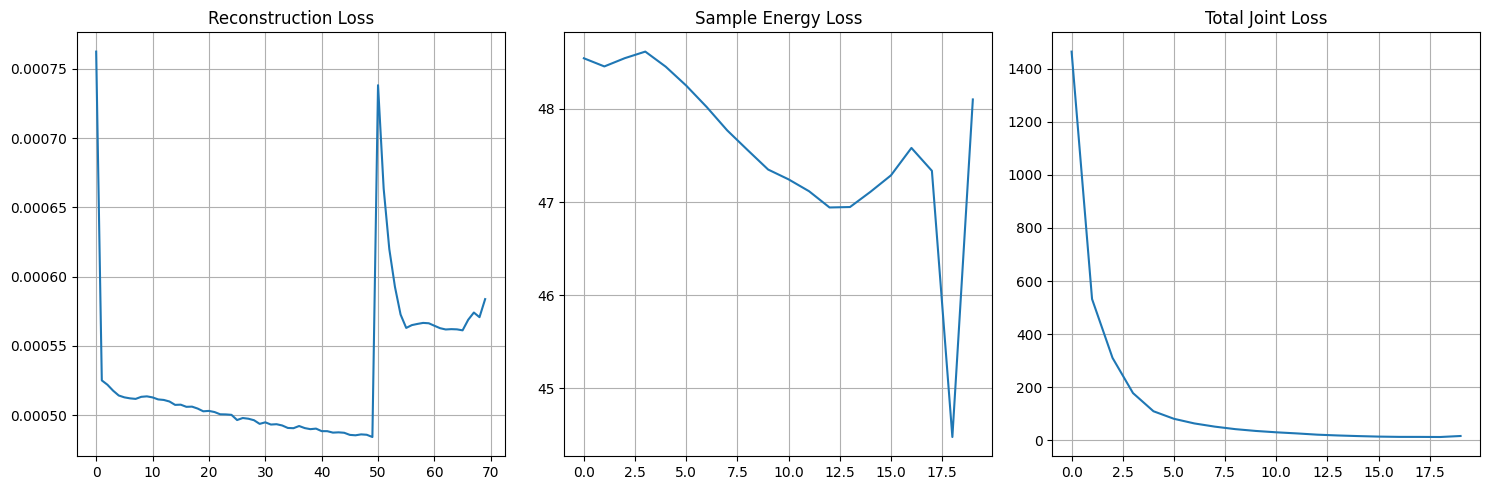

In [68]:
history = train_dagmm_joint(
    model, 
    train_loader, 
    ae_warmup_epochs=AE_WARMUP_EPOCHS, 
    distill_epochs=DISTILL_EPOCHS, 
    joint_epochs=JOINT_FINETUNE_EPOCHS
)

# Plot training curves
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history['recon_loss'])
plt.title('Reconstruction Loss')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history['energy_loss'])
plt.title('Sample Energy Loss')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(history['total_loss'])
plt.title('Total Joint Loss')
plt.grid(True)
plt.tight_layout()
plt.show()


## 6. Global GMM Parameter Estimation
Aggregating the learned mixture parameters from the entire training set to compute final inference statistics.


In [69]:
def get_global_gmm_params(model, loader):
    """Estimate global GMM parameters from the training set after joint optimization."""
    model.eval()
    all_z = []
    all_gamma = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Aggregating GMM stats'):
            x = batch.to(device)
            z, _, gamma = model(x)
            all_z.append(z)
            all_gamma.append(gamma)
            
    z_all = torch.cat(all_z, dim=0)
    gamma_all = torch.cat(all_gamma, dim=0)
    
    phi, mu, sigma = compute_gmm_params(z_all, gamma_all)
    return phi, mu, sigma

print("Estimating final GMM parameters...")
final_phi, final_mu, final_sigma = get_global_gmm_params(model, train_loader)


Estimating final GMM parameters...


Aggregating GMM stats: 100%|██████████| 200/200 [00:01<00:00, 155.36it/s]


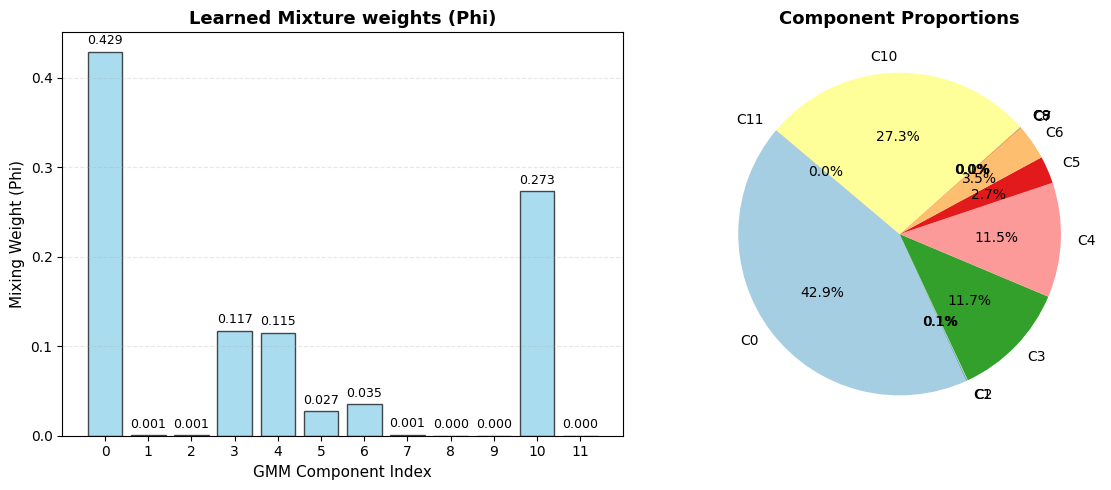


Detailed Component Weights:
------------------------------
  Component  0: 0.429143 ( 42.91%)
  Component  1: 0.000704 (  0.07%)
  Component  2: 0.000815 (  0.08%)
  Component  3: 0.117005 ( 11.70%)
  Component  4: 0.114918 ( 11.49%)
  Component  5: 0.027404 (  2.74%)
  Component  6: 0.035330 (  3.53%)
  Component  7: 0.000876 (  0.09%)
  Component  8: 0.000195 (  0.02%)
  Component  9: 0.000173 (  0.02%)
  Component 10: 0.273312 ( 27.33%)
  Component 11: 0.000124 (  0.01%)
------------------------------


In [70]:
# Check Component Distribution (Phi)
phi_np = final_phi.cpu().numpy()

plt.figure(figsize=(12, 5))

# Plot 1: Bar Chart of Mixing Weights
plt.subplot(1, 2, 1)
bars = plt.bar(range(K_COMPONENTS), phi_np, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('GMM Component Index', fontsize=11)
plt.ylabel('Mixing Weight (Phi)', fontsize=11)
plt.title('Learned Mixture weights (Phi)', fontsize=13, fontweight='bold')
plt.xticks(range(K_COMPONENTS))
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Pie Chart for Relative Proportions
plt.subplot(1, 2, 2)
plt.pie(phi_np, labels=[f'C{i}' for i in range(K_COMPONENTS)], autopct='%1.1f%%', 
        startangle=140, colors=plt.cm.Paired(np.linspace(0, 1, K_COMPONENTS)))
plt.title('Component Proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDetailed Component Weights:")
print("-" * 30)
for i, p in enumerate(phi_np):
    print(f"  Component {i:2d}: {p:.6f} ({p*100:6.2f}%)")
print("-" * 30)


## 7. Performance Evaluation: Sample Energy Scoring
Using the learned global Gaussian parameters to compute the Negative Log-Likelihood (Energy) for each test pixel.


In [71]:
def score_dagmm(model, loader, phi, mu, sigma):
    """Compute energy scores for all samples in loader."""
    model.eval()
    all_scores = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc='Scoring test data'):
            if isinstance(batch, (list, tuple)):
                x, labels = batch
                all_labels.append(labels)
            else:
                x = batch
            
            x = x.to(device)
            z, _, _ = model(x)
            
            # Compute energy for this batch
            # We need to adapt compute_energy to return individual scores
            N = z.shape[0]
            K = phi.shape[0]
            D = z.shape[1]
            z_centered = z.unsqueeze(1) - mu.unsqueeze(0)
            
            energies = []
            for k in range(K):
                inv_sigma = torch.inverse(sigma[k])
                det_sigma = torch.det(sigma[k]) + 1e-30
                dist = torch.matmul(torch.matmul(z_centered[:, k, :].unsqueeze(1), inv_sigma), 
                                    z_centered[:, k, :].unsqueeze(-1)).squeeze()
                
                log_phi_k = torch.log(phi[k] + 1e-10)
                log_det_k = torch.log(det_sigma)
                log_prob_k = log_phi_k - 0.5 * D * np.log(2 * np.pi) - 0.5 * log_det_k - 0.5 * dist
                if log_prob_k.dim() == 0: # single sample case
                    log_prob_k = log_prob_k.unsqueeze(0)
                energies.append(log_prob_k.unsqueeze(-1))
            
            energies = torch.cat(energies, dim=1)
            sample_energy = -torch.logsumexp(energies, dim=1)
            all_scores.append(sample_energy.cpu())
    
    scores = torch.cat(all_scores, dim=0).numpy()
    
    if all_labels:
        labels = torch.cat(all_labels, dim=0).numpy()
        return scores, labels
    return scores

print('Scoring test data with DAGMM...')
scores, y_test = score_dagmm(model, test_loader, final_phi, final_mu, final_sigma)

# Convert labels to binary (assuming 2 is normal)
y_binary = (y_test != 2).astype(int)

roc_auc = roc_auc_score(y_binary, scores)
pr_auc = average_precision_score(y_binary, scores)

print(f'\nDAGMM Results ({food_type})')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'PR-AUC:  {pr_auc:.4f}')


Scoring test data with DAGMM...


Scoring test data: 100%|██████████| 200/200 [00:02<00:00, 83.99it/s]


DAGMM Results (Almond)
ROC-AUC: 0.9715
PR-AUC:  0.8061


Computing membership assignments for test set...


Estimating assignments: 100%|██████████| 200/200 [00:01<00:00, 152.01it/s]


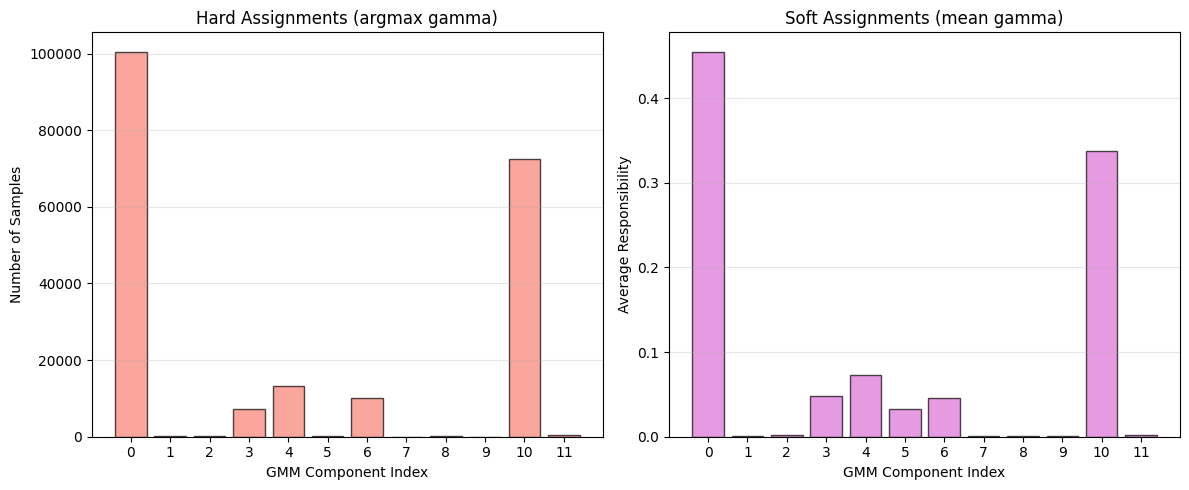


Test Component Distribution:
  Component  0:  100,519 samples (49.08%) | Avg Soft: 0.4550
  Component  1:       77 samples ( 0.04%) | Avg Soft: 0.0014
  Component  2:      253 samples ( 0.12%) | Avg Soft: 0.0021
  Component  3:    7,205 samples ( 3.52%) | Avg Soft: 0.0483
  Component  4:   13,332 samples ( 6.51%) | Avg Soft: 0.0725
  Component  5:      256 samples ( 0.12%) | Avg Soft: 0.0329
  Component  6:    9,977 samples ( 4.87%) | Avg Soft: 0.0458
  Component  7:        5 samples ( 0.00%) | Avg Soft: 0.0008
  Component  8:       97 samples ( 0.05%) | Avg Soft: 0.0007
  Component  9:       17 samples ( 0.01%) | Avg Soft: 0.0003
  Component 10:   72,601 samples (35.45%) | Avg Soft: 0.3378
  Component 11:      461 samples ( 0.23%) | Avg Soft: 0.0024


In [72]:
# 7.1 Component Assignment Analysis (Test Set)
def get_test_assignments(model, loader):
    """Estimate component membership for test samples."""
    model.eval()
    all_gamma = []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Estimating assignments'):
            if isinstance(batch, (list, tuple)):
                x = batch[0]
            else:
                x = batch
            x = x.to(device)
            _, _, gamma = model(x)
            all_gamma.append(gamma.cpu())
    return torch.cat(all_gamma, dim=0)

print("Computing membership assignments for test set...")
test_gamma = get_test_assignments(model, test_loader)
test_assignments = torch.argmax(test_gamma, dim=1).numpy()

# Calculate assignment counts
unique, counts = np.unique(test_assignments, return_counts=True)
assignment_dict = dict(zip(unique, counts))

# Visualization
plt.figure(figsize=(12, 5))

# Plot 1: Histogram of assignments
plt.subplot(1, 2, 1)
plt.bar(range(K_COMPONENTS), [assignment_dict.get(i, 0) for i in range(K_COMPONENTS)], 
        color='salmon', edgecolor='black', alpha=0.7)
plt.xlabel('GMM Component Index')
plt.ylabel('Number of Samples')
plt.title('Hard Assignments (argmax gamma)')
plt.xticks(range(K_COMPONENTS))
plt.grid(axis='y', alpha=0.3)

# Plot 2: Average membership (Soft assignments)
plt.subplot(1, 2, 2)
avg_gamma = torch.mean(test_gamma, dim=0).numpy()
plt.bar(range(K_COMPONENTS), avg_gamma, color='orchid', edgecolor='black', alpha=0.7)
plt.xlabel('GMM Component Index')
plt.ylabel('Average Responsibility')
plt.title('Soft Assignments (mean gamma)')
plt.xticks(range(K_COMPONENTS))
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTest Component Distribution:")
for i in range(K_COMPONENTS):
    count = assignment_dict.get(i, 0)
    print(f"  Component {i:2d}: {count:8,d} samples ({100*count/len(test_assignments):5.2f}%) | Avg Soft: {avg_gamma[i]:.4f}")


## 8. Results Visualization
Spatial decision maps, ROC/PR curves, and anomaly score distribution analysis.


/tmp/ipykernel_59287/2154782371.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


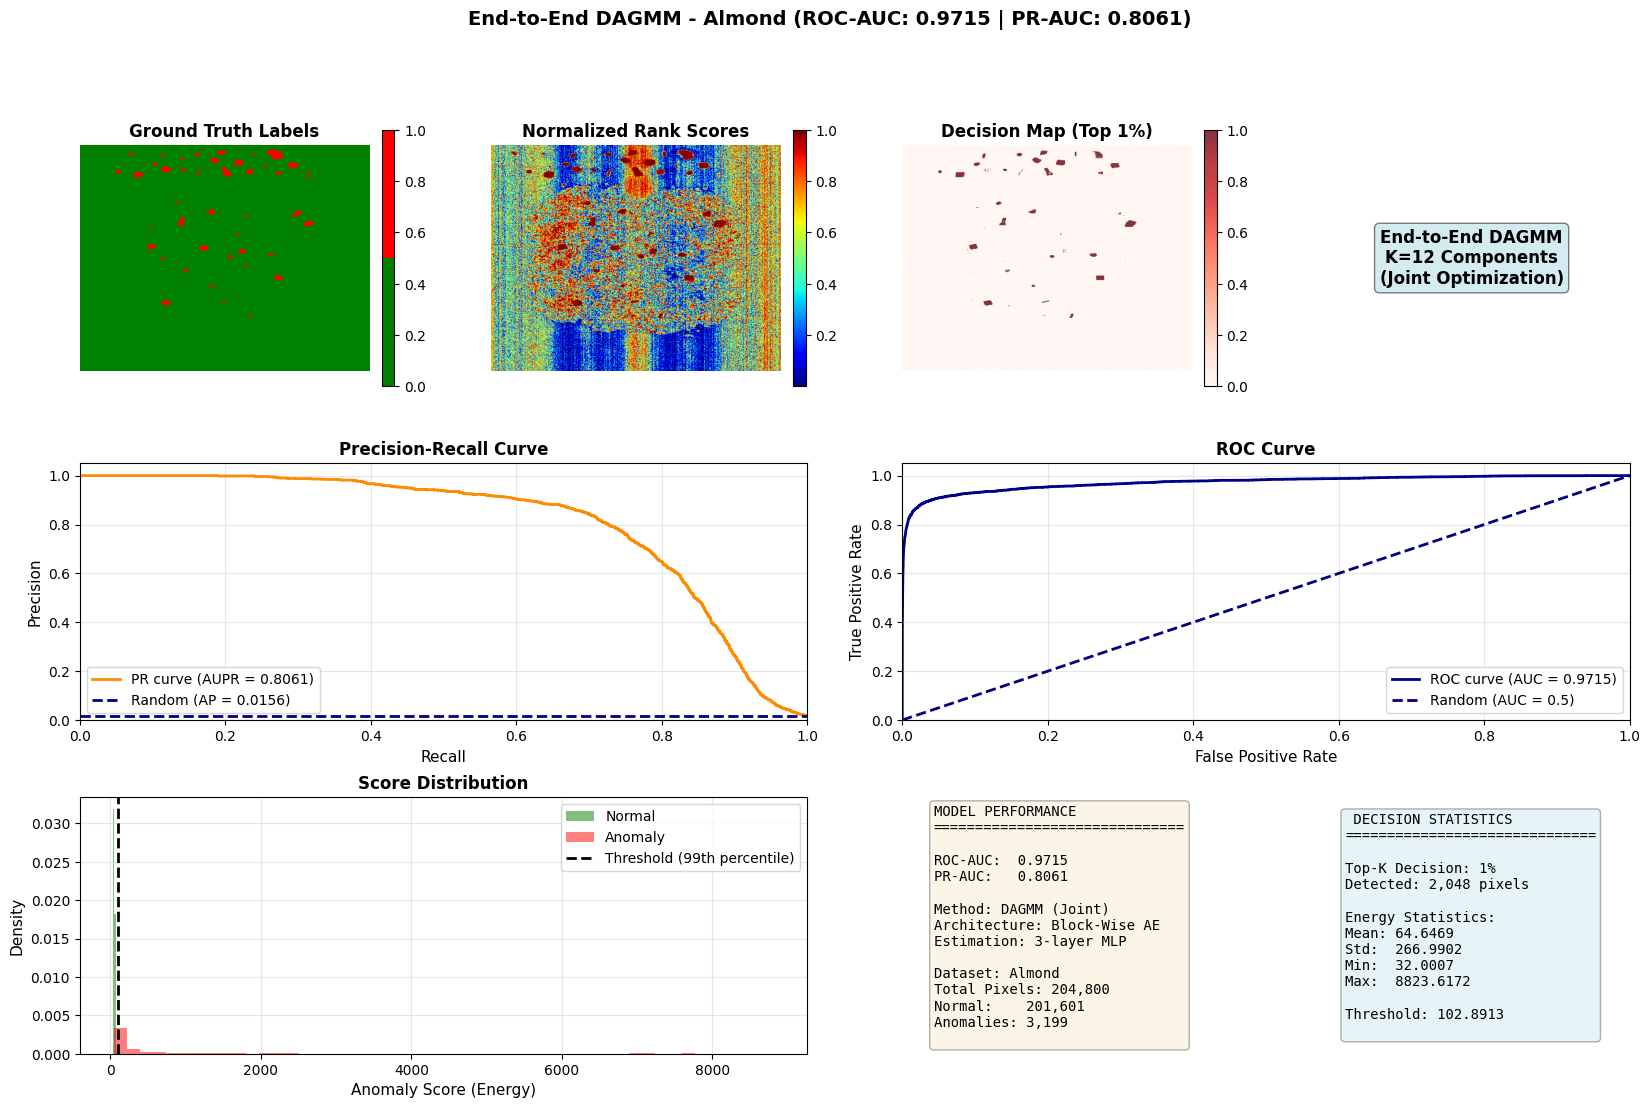

In [73]:
from scipy.stats import rankdata
from matplotlib.colors import ListedColormap

# Compute normalized rank scores for visualization
rank_scores = rankdata(scores, method="average") / len(scores)
normalized_scores = rank_scores

# Compute decision threshold (top K%)
k_pixels = int(np.ceil(len(scores) * TOP_K_PERCENT / 100.0))
top_k_indices = np.argsort(-scores)[:k_pixels]
pixel_decision = np.zeros(len(scores), dtype=bool)
pixel_decision[top_k_indices] = True

# Reshape for spatial visualization
H, W = test_dataset.shape
score_map = scores.reshape(H, W)
normalized_score_map = normalized_scores.reshape(H, W)
label_map = y_binary.reshape(H, W)
decision_map = pixel_decision.reshape(H, W)

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Spatial visualizations
ax2 = fig.add_subplot(gs[0, 0])
cmap_binary = ListedColormap(['green', 'red'])
im2 = ax2.imshow(label_map, cmap=cmap_binary)
ax2.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[0, 1])
im3 = ax3.imshow(normalized_score_map, cmap='jet')
ax3.set_title('Normalized Rank Scores', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = fig.add_subplot(gs[0, 2])
im4 = ax4.imshow(decision_map, cmap='Reds', alpha=0.8)
ax4.set_title(f'Decision Map (Top {TOP_K_PERCENT}%)', fontsize=12, fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

ax_info = fig.add_subplot(gs[0, 3])
ax_info.text(0.5, 0.5, f'End-to-End DAGMM\nK={K_COMPONENTS} Components\n(Joint Optimization)', 
             ha='center', va='center', fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
ax_info.axis('off')

# Row 2: PR and ROC curves
ax5 = fig.add_subplot(gs[1, 0:2])
precision, recall, _ = precision_recall_curve(y_binary, scores)
ax5.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUPR = {pr_auc:.4f})')
baseline = y_binary.sum() / len(y_binary)
ax5.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random (AP = {baseline:.4f})')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('Recall', fontsize=11)
ax5.set_ylabel('Precision', fontsize=11)
ax5.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2:4])
fpr, tpr, _ = roc_curve(y_binary, scores)
ax6.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax6.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax6.set_xlim([0.0, 1.0])
ax6.set_ylim([0.0, 1.05])
ax6.set_xlabel('False Positive Rate', fontsize=11)
ax6.set_ylabel('True Positive Rate', fontsize=11)
ax6.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)

# Row 3: Distribution and statistics
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.hist(scores[y_binary == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax7.hist(scores[y_binary == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
ax7.axvline(np.percentile(scores, 100 - TOP_K_PERCENT), color='black', linestyle='--', 
            label=f'Threshold ({100-TOP_K_PERCENT}th percentile)', linewidth=2)
ax7.set_xlabel('Anomaly Score (Energy)', fontsize=11)
ax7.set_ylabel('Density', fontsize=11)
ax7.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[2, 2])
stats_text_left = f"""MODEL PERFORMANCE
{'='*30}

ROC-AUC:  {roc_auc:.4f}
PR-AUC:   {pr_auc:.4f}

Method: DAGMM (Joint)
Architecture: Block-Wise AE
Estimation: 3-layer MLP

Dataset: {food_type}
Total Pixels: {len(scores):,}
Normal:    {(y_binary == 0).sum():,}
Anomalies: {(y_binary == 1).sum():,}
"""
ax8.text(0.1, 0.5, stats_text_left, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax8.axis('off')

ax9 = fig.add_subplot(gs[2, 3])
stats_text_right = f""" DECISION STATISTICS
{'='*30}

Top-K Decision: {TOP_K_PERCENT}%
Detected: {pixel_decision.sum():,} pixels

Energy Statistics:
Mean: {scores.mean():.4f}
Std:  {scores.std():.4f}
Min:  {scores.min():.4f}
Max:  {scores.max():.4f}

Threshold: {np.percentile(scores, 100 - TOP_K_PERCENT):.4f}
"""
ax9.text(0.1, 0.5, stats_text_right, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax9.axis('off')

plt.suptitle(f'End-to-End DAGMM - {food_type} (ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f})', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## 9. Model and Results Export
Saving the trained DAGMM weights, global mixture parameters, and evaluation metrics for reproducibility.


In [74]:
# Save DAGMM Model and Results
save_path = f'blr_dagmm_{food_type.lower()}.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'phi': final_phi,
    'mu': final_mu,
    'sigma': final_sigma,
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'config': {
        'input_dim': input_dim,
        'latent_dim': LATENT_DIM,
        'num_windows': NUM_WINDOWS,
        'k_components': K_COMPONENTS,
        'lambda_energy': LAMBDA_ENERGY,
        'lambda_cov': LAMBDA_COV
    }
}, save_path)

print(f'Model saved to {save_path}')

# Save results to JSON
result_json = {
    'method': 'End-to-End DAGMM',
    'food_type': food_type,
    'metrics': {
        'roc_auc': float(roc_auc),
        'pr_auc': float(pr_auc)
    },
    'config': {
        'latent_dim': LATENT_DIM,
        'num_windows': NUM_WINDOWS,
        'k_components': K_COMPONENTS,
        'lambda_energy': LAMBDA_ENERGY,
        'lambda_cov': LAMBDA_COV
    }
}

json_path = f'blr_dagmm_{food_type.lower()}.json'
with open(json_path, 'w') as f:
    json.dump(result_json, f, indent=2)

print(f'Results saved to {json_path}')


Model saved to blr_dagmm_almond.pth
Results saved to blr_dagmm_almond.json


## 10. Latent Space Analysis (UMAP)
Dimensionality reduction of the refined latent space to visualize separation between normal and anomalous spectral clusters.



Generating UMAP visualization of DAGMM latent space...


Extracting latents: 100%|██████████| 200/200 [00:01<00:00, 122.08it/s]
/home/alfi/miniforge3/envs/rapidsai/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fit complete. Shape: (204800, 2)


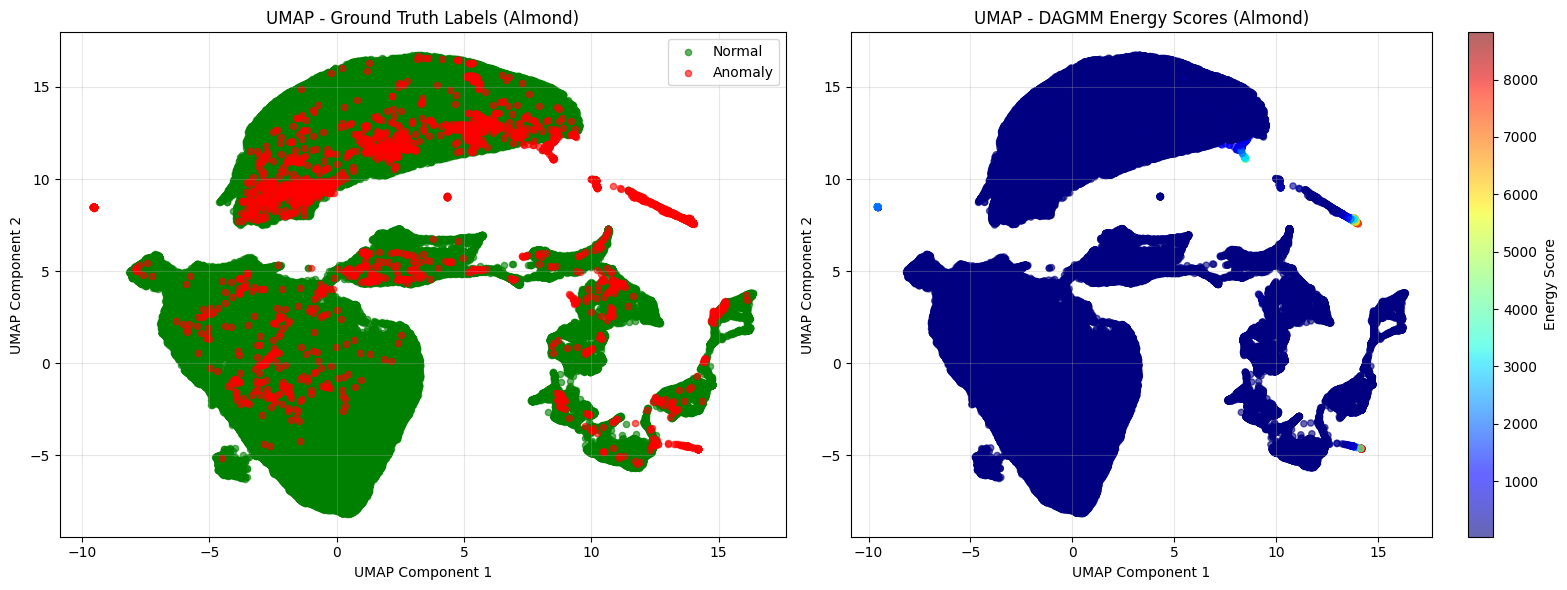

In [75]:
# UMAP Visualization of DAGMM Latent Space
from umap import UMAP

print('\nGenerating UMAP visualization of DAGMM latent space...')

# Extract latents
model.eval()
all_z = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Extracting latents'):
        if isinstance(batch, (list, tuple)):
            x = batch[0]
        else:
            x = batch
        x = x.to(device)
        z, _, _ = model(x)
        all_z.append(z.cpu())
Z_test = torch.cat(all_z, dim=0).numpy()

# Fit UMAP
umap_reducer = UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
Z_test_umap = umap_reducer.fit_transform(Z_test)

print(f'UMAP fit complete. Shape: {Z_test_umap.shape}')

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: UMAP colored by ground truth label
ax1 = axes[0]
ax1.scatter(Z_test_umap[y_binary == 0, 0], Z_test_umap[y_binary == 0, 1],
           c='green', label='Normal', alpha=0.6, s=20)
ax1.scatter(Z_test_umap[y_binary == 1, 0], Z_test_umap[y_binary == 1, 1],
           c='red', label='Anomaly', alpha=0.6, s=20)
ax1.set_xlabel('UMAP Component 1')
ax1.set_ylabel('UMAP Component 2')
ax1.set_title(f'UMAP - Ground Truth Labels ({food_type})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: UMAP colored by DAGMM energy score
ax2 = axes[1]
scatter3 = ax2.scatter(Z_test_umap[:, 0], Z_test_umap[:, 1],
                       c=scores, cmap='jet', alpha=0.6, s=20)
ax2.set_xlabel('UMAP Component 1')
ax2.set_ylabel('UMAP Component 2')
ax2.set_title(f'UMAP - DAGMM Energy Scores ({food_type})')
cbar = plt.colorbar(scatter3, ax=ax2)
cbar.set_label('Energy Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
